# Benchmark: vLLM Model Streamer on DO Spaces

This benchmark evaluates the capability of DO Spaces (S3-Compatible Object Storage) to store AI model weights and serves as a reference for custom solution design and parameter tuning.

**Key Consolutions**

- Download throughput for a single model streamer: approximately **50 Gb/s**.
- Aggregated download throughput for multiple streamers: more than **280 Gb/s**.
- Supported number of concurrent model streamers: up to **20** (reserving some system capacity to accommodate bursts and other factors).
- Adoption: **minimal** workload modifications (limited to startup parameters and environment variable) and **flexible**, as it is independent of VPCs.
- Cost Effectiveness: low cost for data storage, with free data transfer from [DO Spaces](https://docs.digitalocean.com/products/spaces/details/pricing/#bandwidth) to [droplets](https://docs.digitalocean.com/products/droplets/details/pricing/#bandwidth-billing) within the same region.

<span style="color:blue">**Using DO Spaces to store AI model weights is a highly cost-effective and scalable solution, delivering first-class performance and easy adoption compared to alternative approaches.**</span>


## vLLM Model Streamer

[Run:ai Model Streamer](https://github.com/run-ai/runai-model-streamer/blob/master/docs/README.md) is a library that reads tensors from local folders or S3-Compatible Object Storage concurrently and streams them directly into GPU memory. 

[vLLM](https://docs.vllm.ai/en/stable/models/extensions/runai_model_streamer/) can load weights in the Safetensors format using Run:ai Model Streamer, consolidating model download and loading times to reduce server startup latency.

**Example - Stream and run the Llama 70B model (131.4 GiB) stored in DO Spaces**

AWS_ENDPOINT_URL=https://atl1.digitaloceanspaces.com \
AWS_ACCESS_KEY_ID=************ \
AWS_SECRET_ACCESS_KEY=************ \
RUNAI_STREAMER_S3_USE_VIRTUAL_ADDRESSING=0 \
AWS_EC2_METADATA_DISABLED=true \
vllm serve s3://rs-high-perf-bucket/models/Llama-3.1-70B-Instruct \
  --load-format runai_streamer \
  --model-loader-extra-config '{"concurrency":8, "memory_limit":2684354560}' \
  --served-model-name meta-llama/Llama-3.1-70B-Instruct

### How it works with Object Storage

The model streamer first calls **S3:ListObjects** to retrieve all objects in a specific folder in the bucket, then uses **S3:HeadObject** to fetch metadata for each object, and finally calls **S3:GetObject** (with HTTP Range Requests) to download the model weights (multiple large files) concurrently.

<span style="color:red">**The model streamer uses HTTP/2 (allowing multiple requests per session) and supports multiple sessions, enabling it to send hundreds or even thousands of HTTP requests concurrently, which can easily overload the Object Storage if not carefully managed.**</span>

By default, [the chunk size](https://github.com/run-ai/runai-model-streamer/blob/master/docs/src/env-vars.md#default-value-1) for HTTP Range Requests when working with Object Storage is set to **8,388,608 bytes (8 MiB)**. [The memory limit](https://github.com/run-ai/runai-model-streamer/blob/master/docs/src/env-vars.md#runai_streamer_memory_limit) controls the CPU buffer size used to store tensors before they are transferred to GPU memory, and can also indirectly determine the number of concurrent requests.

For example: if the memory_limit is set to 2,684,354,560 bytes with a chunk size of 8,388,608 bytes, the model streamer of a single vLLM instance can generate **more than 320 concurrent requests per second** (RPS).

Streaming the Llama 70B model (131.4 GiB) using the above settings (**8 concurrent sessions, with a memory limit of 2.5 GiB and a chunk size of 8 MiB**) generates a total of approximately **17,500 (131.4 GiB / 8 MiB)** HTTP requests—about 17,400 S3:GetObject requests, with a small number of S3:HeadObject and S3:ListObjects requests.

### Performance Factors

Many factors can influence model streaming throughput, including the supported RPS and outbound bandwidth of the Object Storage, the inbound bandwidth of the vLLM model streamer, the RTT and network bandwidth between them, as well as the concurrency, chunk_size, and memory_limit of the vLLM model streamer.

To increase the throughput of a single vLLM model streamer, in addition to using a bucket in the same region to reduce RTT, performance can be improved by increasing concurrency and memory_limit and adjusting chunk_size, which enables more concurrent requests and better utilization of network bandwidth.

To increase the throughput of multiple vLLM model streamers, these parameters should be optimized to prevent overloading the Object Storage, **particularly with respect to the RPS**. If overload occurs, some requests may be rejected with HTTP 503 by the Object Storage, and after timeouts and retries by the streamer, overall system throughput can drop significantly, potentially causing the streamer to fail if rejections are excessive.

## Benchmark Test Design and Setup

A high-performance bucket in the ATL1 region of DO Spaces—was provisioned for this test, capable of handling more concurrent requests and delivering higher throughput. The Llama 3.1 70B model (131.4 GiB) was preloaded into the bucket.

The vLLM model streamer is containerized using [the provided Dockerfile](https://github.com/rxsalad/vllm-runai-streamer/blob/main/benchmarker/Dockerfile) and configured with 8 sessions, a memory limit of 2.5 GiB, and a chunk size of 8 MiB. During execution, it collects key metrics (such as streaming time, throughput, server startup time and timestamps, etc) and [stores them in MongoDB](https://github.com/rxsalad/benchmarking-database), which are subsequently exported as CSV for data analysis.

A DOKS cluster with 20 1-GPU MI325 worker nodes was provisioned, with the test container image preloaded on all nodes. [Using the provided K8S yaml file](https://github.com/rxsalad/vllm-runai-streamer/blob/main/model-streamer-benchmarker.yaml), 1, 2, … up to 20 vLLM model streamer pods were launched concurrently.

**The final analysis combines [these collected metrics](https://github.com/rxsalad/vllm-runai-streamer/blob/main/llama_70b_vllm_model_streamer_20260307.csv) from the pods along with metrics from DO Spaces for correlation analysis and cross-checking.**

## Detailed Results and Analysis

The test executed 210 downloads of the Llama 70B model, transferring approximately **30 TB** of data (**210 x 131.4 GiB**), all completed successfully. During this process, over **3.7 million HTTP requests** (**210 * 131.4 GiB / 8 MiB**) were sent to DO Spaces, with fewer than 200 resulting in HTTP 503 errors (194). Please check the raw test data.

#### Total Requests and Downloads

![stats2](images/stats2.png)

#### Detailed Requests per 20 seconds – Successful and Failed

![stats1](images/stats1.png)

#### Total Requests – Single vs. 20 Concurrency


![rps](images/rps.png)

#### Download Throughput – Single vs. 20 Concurrency

![rps](images/throughput.png)

#### Measured Model Streaming Throughput Across 1–20 Concurrent Clients

- Average Throughput per Client (Gb/s) → min: 14.09, max: 47.24
- Aggregated Throughput (Gb/s) → min: 47.24, max: 281.75


![rps](images/collected_throughput.png)


#### Measured Model Streaming Time and Server Startup Time Across 1–20 Concurrent Clients

![rps](images/collected_time.png)

In [172]:
import json
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy
import numpy as np

%matplotlib inline  

In [173]:
df = pd.read_csv("./llama_70b_vllm_model_streamer_20260307.csv")

In [174]:
# Total model size in GiB
total_GiB = df["model_GiB"].sum()
# Convert to GB (decimal, 1 GB = 10^9 bytes)
total_GB = total_GiB * 1024**3 / 1e9
# Print
print(f"Total data downloaded: {total_GiB:.2f} GiB, {total_GB:.2f} GB")

num_failed = (df['state'] != 'success').sum()
print(f"Number of failed downloads: {num_failed}")

Total data downloaded: 27594.00 GiB, 29628.83 GB
Number of failed downloads: 0


Aggregated Throughput (Gb/s) → min: 47.24, max: 281.75
Average Throughput (Gb/s) → min: 14.09, max: 47.24


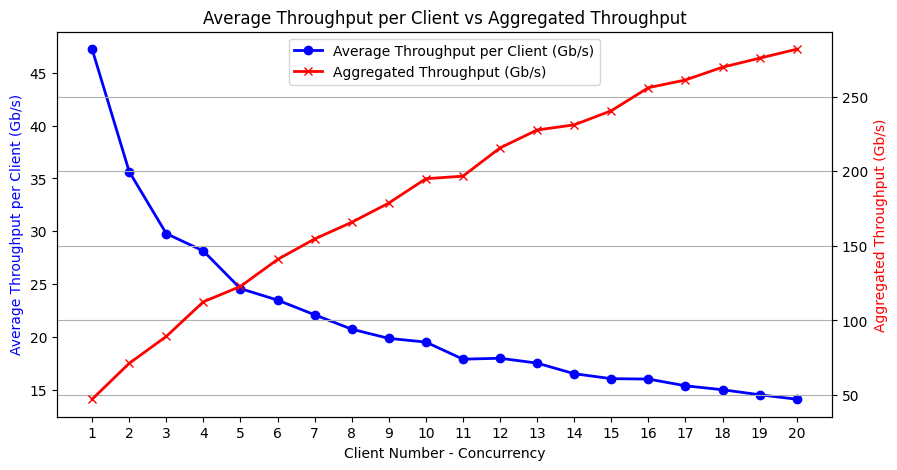

In [175]:
# Aggregated throughput
agg_GiB_s = df.groupby("client_number")["throughput_GiB_s"].sum()

# Average throughput per client
average_GiB_s = df.groupby("client_number")["throughput_GiB_s"].mean()

# Convert GiB/s -> Gb/s
GiB_to_Gb = 8 * (1024**3) / 1e9
agg_Gb_s = agg_GiB_s * GiB_to_Gb
average_Gb_s = average_GiB_s * GiB_to_Gb

# Print min and max
print(f"Aggregated Throughput (Gb/s) → min: {agg_Gb_s.min():.2f}, max: {agg_Gb_s.max():.2f}")
print(f"Average Throughput (Gb/s) → min: {average_Gb_s.min():.2f}, max: {average_Gb_s.max():.2f}")

x = agg_Gb_s.index.astype(int)

# Create figure
fig, ax1 = plt.subplots(figsize=(10,5))

# ax1 → Average Throughput
ax1.plot(x, average_Gb_s.values, marker='o', color='blue', linewidth=2, label="Average Throughput per Client (Gb/s)")
ax1.set_xlabel("Client Number - Concurrency")
ax1.set_ylabel("Average Throughput per Client (Gb/s)", color="blue")
ax1.set_xticks(x)

# ax2 → Aggregated Throughput
ax2 = ax1.twinx()
ax2.plot(x, agg_Gb_s.values, marker='x', color='red', linewidth=2, label="Aggregated Throughput (Gb/s)")
ax2.set_ylabel("Aggregated Throughput (Gb/s)", color="red")

plt.title("Average Throughput per Client vs Aggregated Throughput")
plt.grid(True)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center")

plt.savefig("images/collected_throughput.png", dpi=300, bbox_inches="tight")
plt.show()


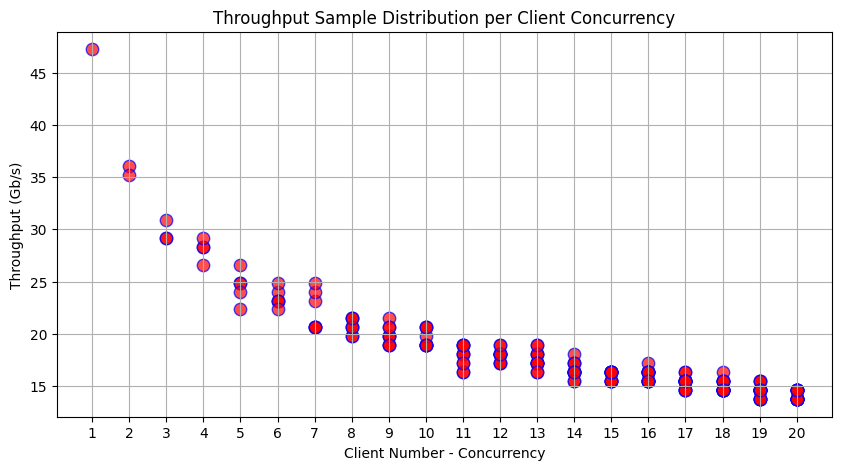

In [176]:
# Convert GiB/s -> Gb/s
GiB_to_Gb = 8 * (1024**3) / 1e9
df["throughput_Gb_s"] = df["throughput_GiB_s"] * GiB_to_Gb

plt.figure(figsize=(10,5))

plt.scatter(
    df["client_number"],
    df["throughput_Gb_s"],
    alpha=0.7,           # slightly more opaque
    color='red',         # bright color
    edgecolor='blue',    # optional: outline for clarity
    s=80                 # optional: increase marker size
)

plt.xlabel("Client Number - Concurrency")
plt.ylabel("Throughput (Gb/s)")
plt.title("Throughput Sample Distribution per Client Concurrency")
plt.xticks(range(1, df["client_number"].max() + 1))
plt.grid(True)

plt.savefig("images/throughput_sample_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Average streaming time (s) → min: 23.98, max: 79.85
Average startup time (s)  → min: 130.02, max: 183.03


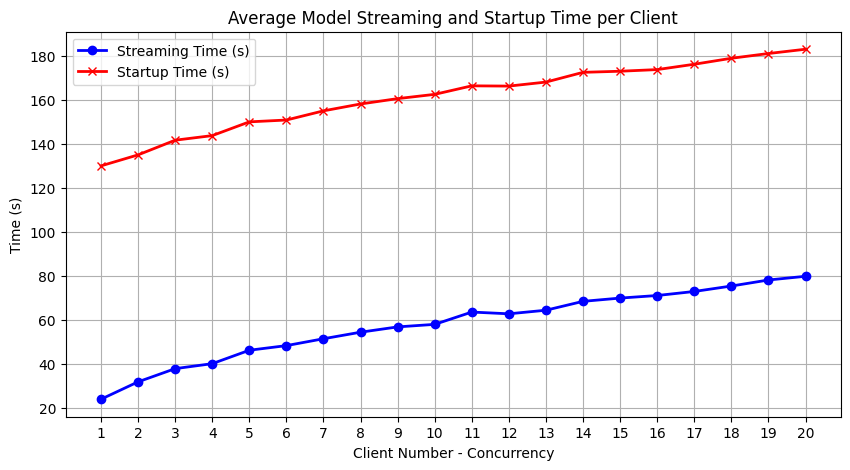

In [177]:
# Compute average times per client
average_time_s = df.groupby("client_number")["time_s"].mean()
average_startup_time_s = df.groupby("client_number")["startup time_s"].mean()

# Print min and max
print(f"Average streaming time (s) → min: {average_time_s.min():.2f}, max: {average_time_s.max():.2f}")
print(f"Average startup time (s)  → min: {average_startup_time_s.min():.2f}, max: {average_startup_time_s.max():.2f}")

# Prepare x-axis
x = average_time_s.index.astype(int)

# Plot both lines together
plt.figure(figsize=(10,5))
plt.plot(x, average_time_s.values, marker='o', color='blue', linewidth=2, label="Streaming Time (s)")
plt.plot(x, average_startup_time_s.values, marker='x', color='red', linewidth=2, label="Startup Time (s)")

plt.xlabel("Client Number - Concurrency")
plt.ylabel("Time (s)")
plt.xticks(x)
plt.title("Average Model Streaming and Startup Time per Client")
plt.grid(True)
plt.legend()

plt.savefig("images/collected_time.png", dpi=300, bbox_inches="tight")
plt.show()

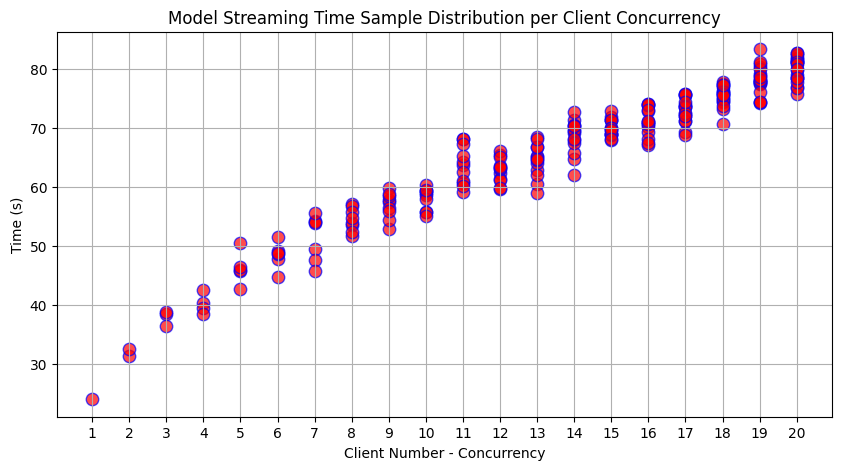

In [178]:
plt.figure(figsize=(10,5))

# Scatter plot for time_s
plt.scatter(
    df["client_number"],
    df["time_s"],
    alpha=0.7,          # slightly more opaque
    color='red',    # bright color for visibility
    edgecolor='blue',  # outline for clarity
    s=80,               # marker size
)

plt.xlabel("Client Number - Concurrency")
plt.ylabel("Time (s)")
plt.title("Model Streaming Time Sample Distribution per Client Concurrency")
plt.xticks(range(1, df["client_number"].max() + 1))
plt.grid(True)

plt.savefig("images/collected_streaming_time_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

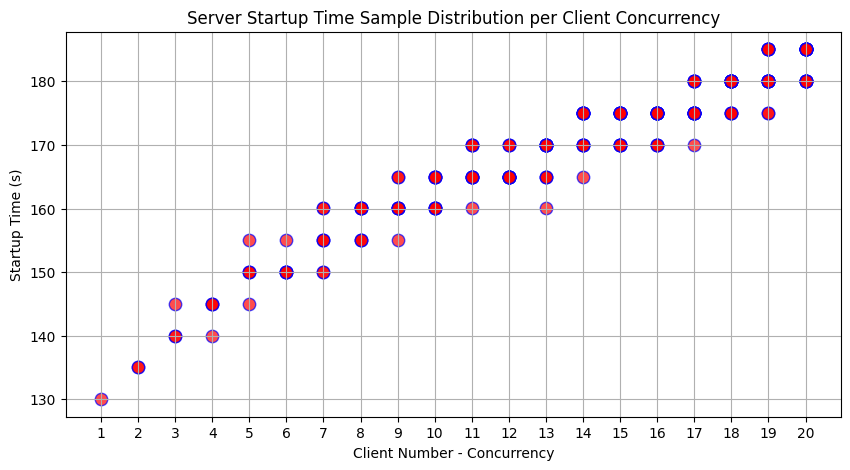

In [179]:
plt.figure(figsize=(10,5))

# Scatter plot for startup_time_s
plt.scatter(
    df["client_number"],
    df["startup time_s"],
    alpha=0.7,          # slightly more opaque
    color='red',      # bright color for visibility
    edgecolor='blue',  # outline for clarity
    s=80,               # marker size
)

plt.xlabel("Client Number - Concurrency")
plt.ylabel("Startup Time (s)")
plt.title("Server Startup Time Sample Distribution per Client Concurrency")
plt.xticks(range(1, df["client_number"].max() + 1))
plt.grid(True)

plt.savefig("images/collected_startup_time_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

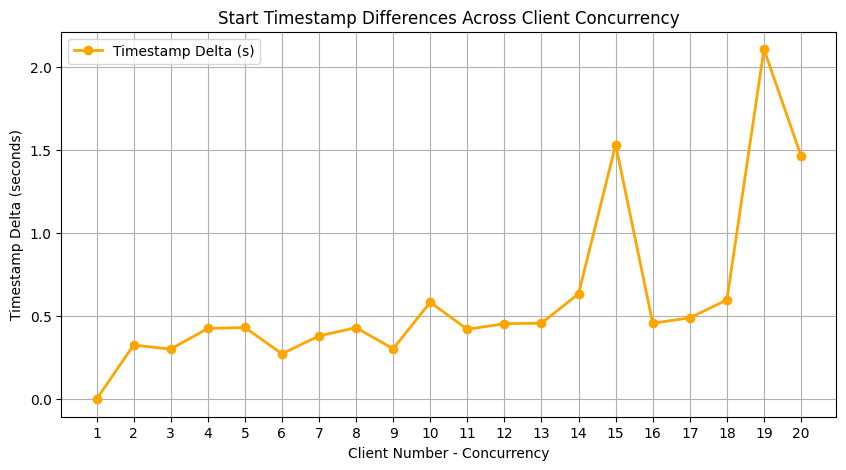

In [180]:
# Convert timestamp column to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Compute timestamp delta (max - min) per client in seconds
timestamp_delta_s = df.groupby("client_number")["timestamp"].agg(lambda x: (x.max() - x.min()).total_seconds())

# Prepare x and y for plotting
x = timestamp_delta_s.index.astype(int)
y = timestamp_delta_s.values

plt.figure(figsize=(10,5))

# Line + scatter for timestamp delta
plt.plot(x, y, marker='o', color='orange', linewidth=2, label="Timestamp Delta (s)")

plt.xlabel("Client Number - Concurrency")
plt.ylabel("Timestamp Delta (seconds)")
plt.title("Start Timestamp Differences Across Client Concurrency")
plt.xticks(range(1, df["client_number"].max() + 1))
plt.grid(True)
plt.legend(loc="upper left")

plt.savefig("images/collected_timestamp_delta.png", dpi=300, bbox_inches="tight")
plt.show()

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               210 non-null    object        
 1   others             210 non-null    object        
 2   served_model_name  210 non-null    object        
 3   timestamp          210 non-null    datetime64[ns]
 4   folder             210 non-null    object        
 5   time_s             210 non-null    float64       
 6   throughput_GiB_s   210 non-null    float64       
 7   task_id            210 non-null    object        
 8   concurrency        210 non-null    int64         
 9   startup time_s     210 non-null    float64       
 10  model              210 non-null    object        
 11  model_GiB          210 non-null    float64       
 12  message            210 non-null    object        
 13  bucket             210 non-null    object        
 14  client_num

In [182]:
from PIL import Image
# Load the image
img = Image.open("images/throughput.png")
# Get original size
width, height = img.size
# Resize to 50%
new_size = (width // 2, height // 2)
resized_img = img.resize(new_size, Image.LANCZOS)
# Save the resized image
resized_img.save("images/throughput_50.png")
print("Resized image saved as images/throughput_50.png")

Resized image saved as images/throughput_50.png
